# DDSP Model Evaluation

This notebook loads a trained DDSP model from a training directory,
takes random chunks from a dataset, runs a forward pass, and evaluates
reconstruction quality via:

- **MSE** (mean squared error)
- **Multi-resolution spectral loss** (MRSTFT via `auraloss`)
- **Overlaid magnitude spectra** (original vs. synthesised)
- **Waveform comparison** plots
- **Playback** of original and synthesised audio (IPython widgets)

In [2]:
# Configuration - point to the experiment config used for training
import os
import yaml

EXPERIMENT_CONFIG = "../configs/complex_sine/experiment_complex_sine_single_1024_frame.yaml"

# Load config and extract values
with open(EXPERIMENT_CONFIG) as f:
    _cfg = yaml.safe_load(f)

# Derive paths and parameters from config
_training_dir = _cfg["experiment"]["training_dir"]
_model_name = _cfg["experiment"]["name"]
MODEL_TRAINING_DIR = os.path.join("..", _training_dir, "synth", _model_name)
DATASET_PATH = _cfg["data"]["dataset_path"]
SAMPLE_RATE = _cfg["audio"]["fs"]
CHUNK_DURATION_S = _cfg["audio"]["chunk_duration_s"]
RESAMPLING_FACTOR = _cfg["model"]["resampling_factor"]

# How many random chunks to evaluate
NUM_SAMPLES = 3

DEVICE = "cuda"  # "cuda" or "cpu"

print(f"Loaded config: {EXPERIMENT_CONFIG}")
print(f"  MODEL_TRAINING_DIR: {MODEL_TRAINING_DIR}")
print(f"  DATASET_PATH: {DATASET_PATH}")
print(f"  SAMPLE_RATE: {SAMPLE_RATE}, CHUNK_DURATION_S: {CHUNK_DURATION_S}, RESAMPLING_FACTOR: {RESAMPLING_FACTOR}")

Loaded config: ../configs/complex_sine/experiment_complex_sine_single_1024_frame.yaml
  MODEL_TRAINING_DIR: ../training/synth/complex_sine_single_1024_frame
  DATASET_PATH: /mnt/mariadata/datasets/surrogate/single_sound/processed
  SAMPLE_RATE: 44100, CHUNK_DURATION_S: 2.0, RESAMPLING_FACTOR: 1024


In [3]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import auraloss.freq
from IPython.display import Audio, display

from ddsp import DDSP, AudioFeatureDataset
from ddsp.utils import find_checkpoint
from ddsp.interfaces import ControlField, ControlSpace, build_control_space

sns.set_theme(style="darkgrid", context="notebook", palette="muted")
torch.set_grad_enabled(False)

print(f"PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}")

PyTorch 2.1.2+cu121  |  CUDA available: True


## 1 - Load the trained model

In [6]:
checkpoint_path = find_checkpoint(MODEL_TRAINING_DIR, typ="last")
print(f"Loading checkpoint: {checkpoint_path}")

# Reconstruct minimal ControlSpace from checkpoint hyperparameters
ckpt = torch.load(checkpoint_path, map_location="cpu")
hparams = ckpt.get("hyper_parameters", {})
feature_dim = int(hparams.get("feature_dim", 0))
latent_size = int(hparams.get("latent_size", 0))
config_name = hparams.get("config_name", None)
synth_configs = hparams.get("synth_configs", [])

# Minimal control space for model instantiation (no extractors needed)
fields = []
if feature_dim > 0:
    fields.append(ControlField(name="features", dim=feature_dim, source="feature", extractor=None))
if latent_size > 0:
    fields.append(ControlField(name="latents", dim=latent_size, source="latent", extractor=None))
model_control_space = ControlSpace(tuple(fields))

ddsp = DDSP.load_from_checkpoint(
    checkpoint_path,
    strict=True,
    device=DEVICE,
    control_space=model_control_space,
).to(DEVICE)
ddsp.eval()

print(f"Model loaded  |  fs={ddsp.fs}  resampling_factor={ddsp.resampling_factor}")
print(f"  feature_dim={ddsp.feature_dim}  latent_size={ddsp.latent_size}")
print(f"  config_name={config_name}")
print(f"  synths: {[s.jit_name for s in ddsp.synths]}")
print(f"  total synth params: {ddsp._total_synth_params}")

Loading checkpoint: ../training/synth/complex_sine_single_1024_frame/last.ckpt
Building synthesizers..., resampling_factor: 1024
Model loaded  |  fs=44100  resampling_factor=1024
  feature_dim=0  latent_size=512
  config_name=experiment_complex_sine_single_1024_frame
  synths: ['ComplexSineSynth']
  total synth params: 128


/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


## 2 - Load the dataset

In [7]:
# Build the full control space WITH extractors from the config already loaded in cell 1.
# The dataset needs the extractors (loudness, pitch, etc.) to compute features.

print(f"Building control space from config: {EXPERIMENT_CONFIG}")

# Build from YAML, but only keep 'feature' fields (dataset doesn't need 'latent')
all_fields = build_control_space(_cfg["model"]["control_space"])
feature_fields = [fld for fld in all_fields.fields if fld.source == "feature"]
# Re-add latent field if the model uses one (dataset ignores it but shape must match)
if latent_size > 0:
    feature_fields.append(ControlField(name="latents", dim=latent_size, source="latent"))
dataset_control_space = ControlSpace(tuple(feature_fields))

n_signal = int(SAMPLE_RATE * CHUNK_DURATION_S)

dataset = AudioFeatureDataset(
    dataset_path=DATASET_PATH,
    n_signal=n_signal,
    sampling_rate=SAMPLE_RATE,
    resampling_factor=RESAMPLING_FACTOR,
    control_space=dataset_control_space,
    device=DEVICE,
)

print(f"Dataset loaded: {len(dataset)} chunks  |  n_signal={n_signal}  ({CHUNK_DURATION_S}s @ {SAMPLE_RATE} Hz)")
print(f"  dataset feature_dim={dataset_control_space.feature_dim}  latent_dim={dataset_control_space.latent_dim}")

Building control space from config: ../configs/complex_sine/experiment_complex_sine_single_1024_frame.yaml
Loading from cache: /mnt/mariadata/datasets/surrogate/single_sound/audio_cache_16d6097f.lmdb
Dataset loaded: 30 chunks  |  n_signal=88200  (2.0s @ 44100 Hz)
  dataset feature_dim=0  latent_dim=512


/home/btadeusz/code/ddsp_vae/ddsp/audio_feature_dataset.py:192: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  audio_cpu[pos:pos+n_samps] = torch.from_numpy(a_arr)


## 3 - Forward pass and metrics

In [8]:
# Build the multi-resolution STFT loss (same FFT sizes as training)
fft_sizes = np.array([2053, 1021, 509, 257, 129, 65, 33])
mrstft_loss_fn = auraloss.freq.MultiResolutionSTFTLoss(
    fft_sizes=fft_sizes.tolist(),
    hop_sizes=(fft_sizes // 4).tolist(),
    win_lengths=fft_sizes.tolist(),
    perceptual_weighting=True,
    sample_rate=SAMPLE_RATE,
).to(DEVICE)


def evaluate_sample(idx: int):
    """Run a single dataset chunk through the model and return metrics + tensors."""
    audio, features = dataset[idx]
    # audio:    [T_audio]          (on DEVICE)
    # features: [T_ctl, D_feat]    (on DEVICE)

    x_audio   = audio.unsqueeze(0)       # [1, T_audio]
    x_feat    = features.unsqueeze(0)     # [1, T_ctl, D_feat]

    # Forward pass (autoencoder)
    print(x_audio.shape, x_feat.shape)
    y_audio = ddsp(x_audio, x_feat).unsqueeze(1)      # [1, 1, T_audio']
    print("y_audio.shape", y_audio.shape)
    y_audio = y_audio.squeeze(0)         # [1, T_audio']

    # Align lengths
    T = min(x_audio.shape[-1], y_audio.shape[-1])
    x = x_audio[..., :T]
    y = y_audio[..., :T]

    # MSE
    mse = torch.nn.functional.mse_loss(y, x).item()

    # MRSTFT
    x_3d = x.unsqueeze(0) if x.dim() == 2 else x
    y_3d = y.unsqueeze(0) if y.dim() == 2 else y
    mrstft = mrstft_loss_fn(y_3d, x_3d).item()

    return {
        "idx": idx,
        "mse": mse,
        "mrstft": mrstft,
        "x": x.squeeze().cpu().numpy(),
        "y": y.squeeze().cpu().numpy(),
    }


# Pick random samples
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(dataset), size=min(NUM_SAMPLES, len(dataset)), replace=False)

results = []
for idx in sample_indices:
    r = evaluate_sample(int(idx))
    results.append(r)
    print(f"Sample {r['idx']:>4d}  |  MSE = {r['mse']:.6f}  |  MRSTFT = {r['mrstft']:.4f}")

avg_mse    = np.mean([r["mse"] for r in results])
avg_mrstft = np.mean([r["mrstft"] for r in results])
print(f"{'=' * 60}")
print(f"Average      |  MSE = {avg_mse:.6f}  |  MRSTFT = {avg_mrstft:.4f}")

torch.Size([1, 88200]) torch.Size([1, 87, 0])
y_audio.shape torch.Size([1, 1, 1, 89088])
Sample   19  |  MSE = 0.035032  |  MRSTFT = 1.2612
torch.Size([1, 88200]) torch.Size([1, 87, 0])
y_audio.shape torch.Size([1, 1, 1, 89088])
Sample    2  |  MSE = 0.033536  |  MRSTFT = 1.1992
torch.Size([1, 88200]) torch.Size([1, 87, 0])
y_audio.shape torch.Size([1, 1, 1, 89088])
Sample   22  |  MSE = 0.033838  |  MRSTFT = 1.2565
Average      |  MSE = 0.034135  |  MRSTFT = 1.2389


/tmp/ipykernel_4062623/3157228394.py:33: UserWarning: Using a target size (torch.Size([1, 88200])) that is different to the input size (torch.Size([1, 1, 88200])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  mse = torch.nn.functional.mse_loss(y, x).item()


## 4 - Spectrum comparison (original vs. synthesised)

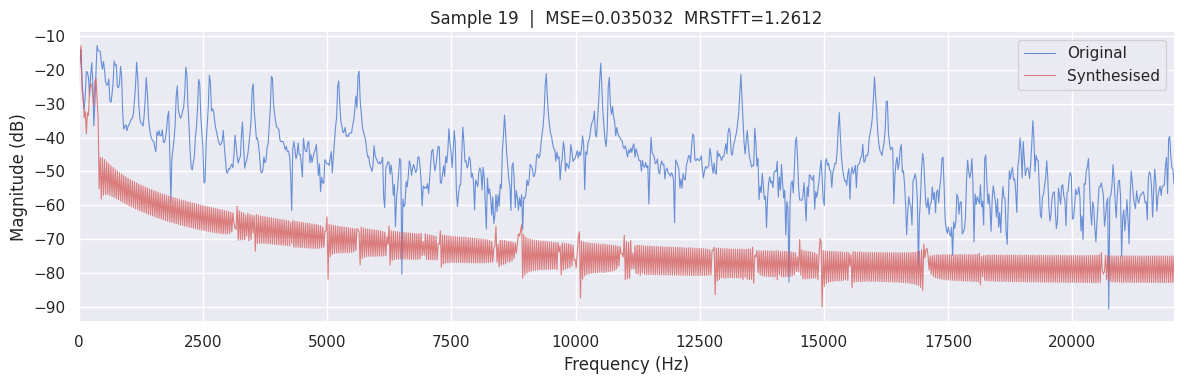

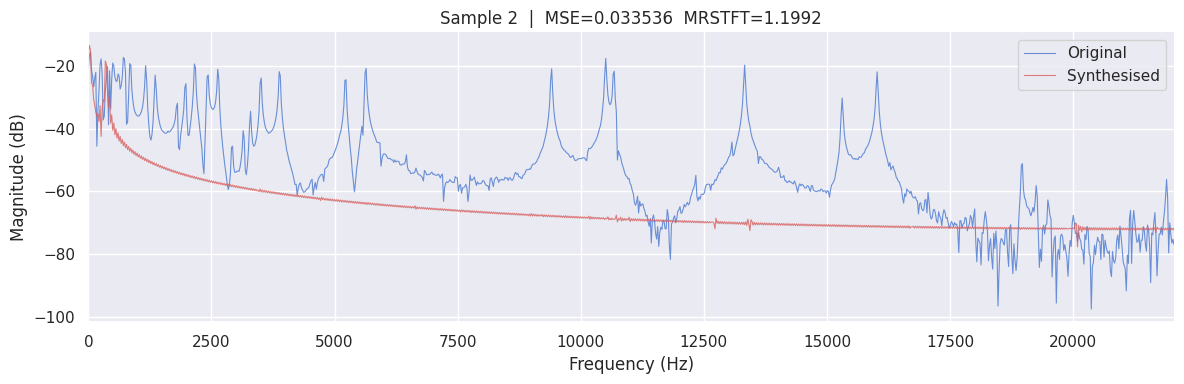

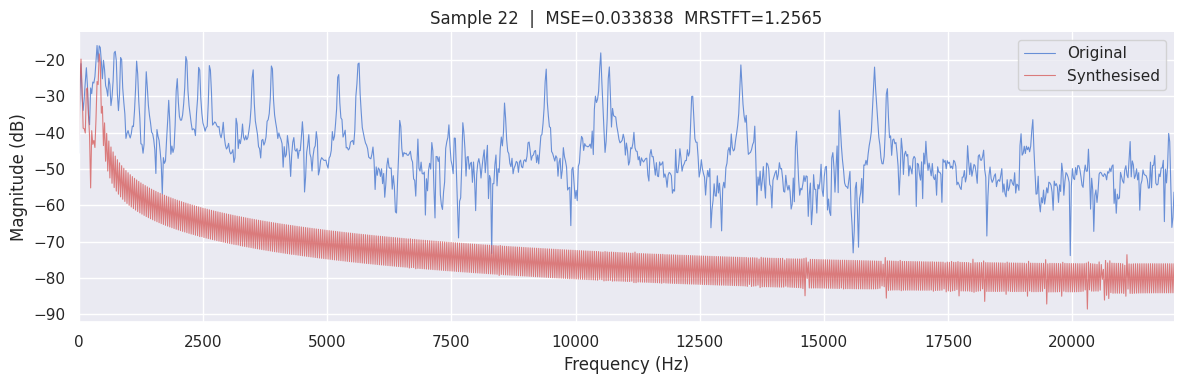

In [9]:
def plot_spectrum(x: np.ndarray, y: np.ndarray, sr: int, title: str = ""):
    """Plot overlaid magnitude spectra of original (x) and synthesised (y).

    Applies a Hann window to reduce spectral leakage.
    """
    n_fft = 2048
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / sr)

    # Apply Hann window to reduce spectral leakage
    window = np.hanning(len(x))
    x_windowed = x * window
    y_windowed = y * window

    X = np.abs(np.fft.rfft(x_windowed, n=n_fft))
    Y = np.abs(np.fft.rfft(y_windowed, n=n_fft))

    # Convert to dB
    X_db = 20 * np.log10(X + 1e-8)
    Y_db = 20 * np.log10(Y + 1e-8)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(freqs, X_db, color=sns.color_palette()[0], alpha=0.8, linewidth=0.8, label="Original")
    ax.plot(freqs, Y_db, color=sns.color_palette()[3], alpha=0.8, linewidth=0.8, label="Synthesised")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title(title or "Magnitude Spectrum")
    ax.legend(frameon=True, fancybox=True)
    ax.set_xlim(0, sr / 2)
    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()


for r in results:
    plot_spectrum(r["x"], r["y"], SAMPLE_RATE,
                 title=f"Sample {r['idx']}  |  MSE={r['mse']:.6f}  MRSTFT={r['mrstft']:.4f}")

## 5 - Waveform comparison

/tmp/ipykernel_4062623/327524456.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


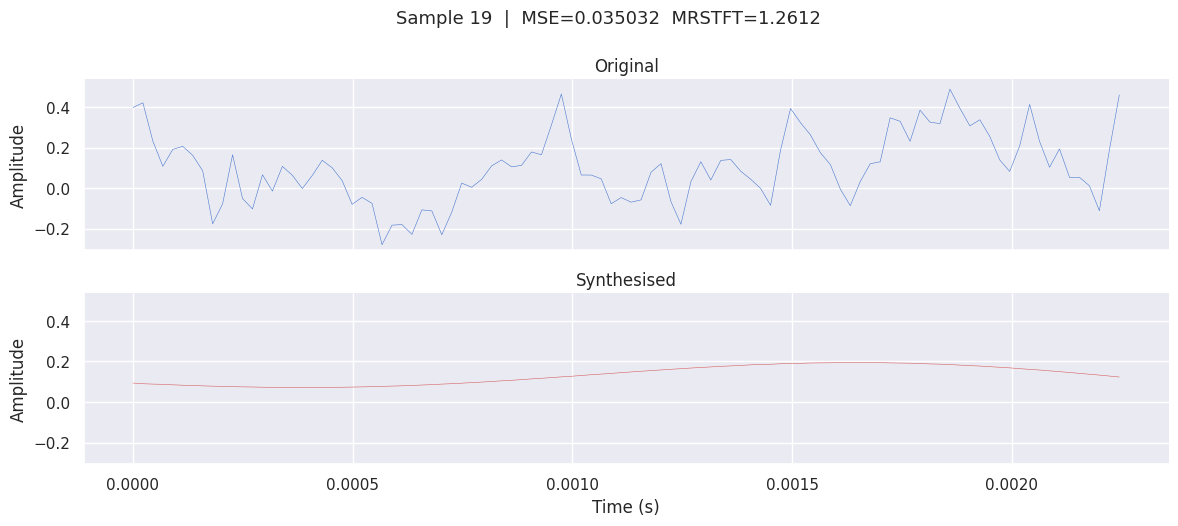

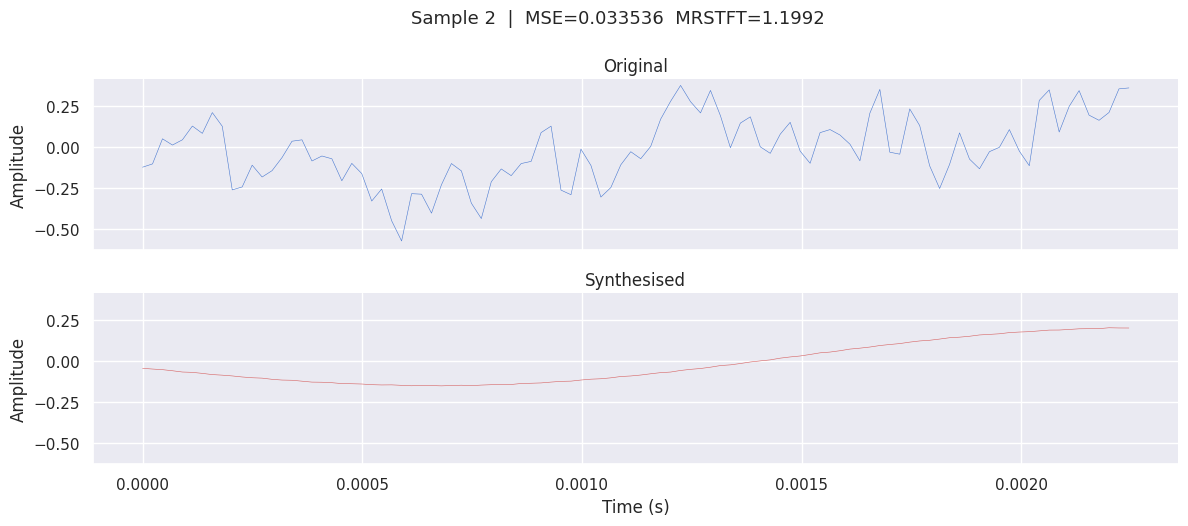

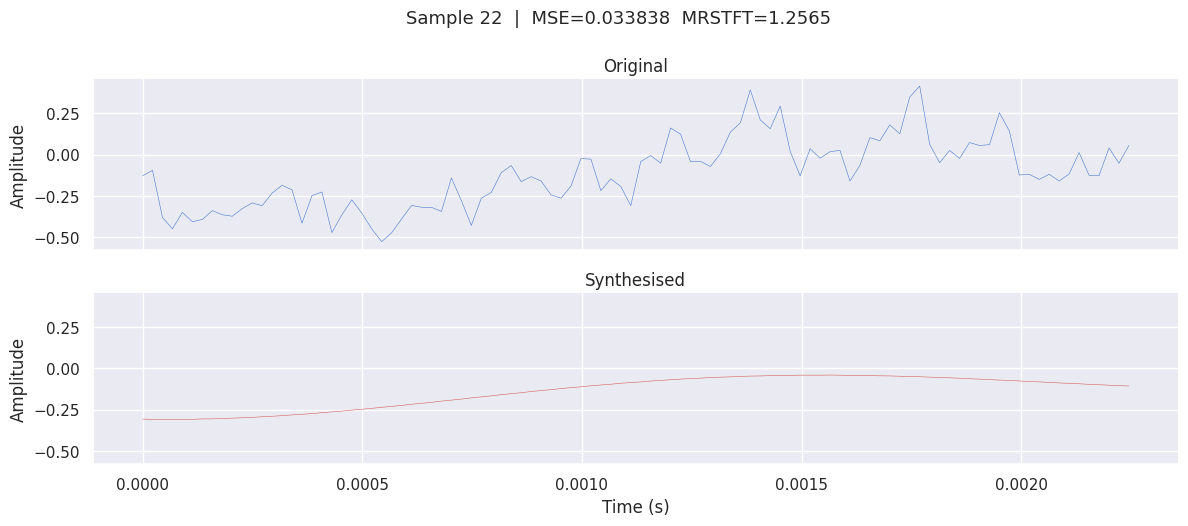

In [10]:
def plot_waveforms(x: np.ndarray, y: np.ndarray, sr: int, title: str = "",
                   display_samples: int | None = None):
    """Plot original and synthesised waveforms stacked vertically.

    Args:
        x: Original waveform
        y: Synthesised waveform
        sr: Sample rate
        title: Plot title
        display_samples: Number of samples to display from the beginning.
                        If None, displays the entire waveform.
    """
    if display_samples is not None:
        x = x[:display_samples]
        y = y[:display_samples]

    t = np.arange(len(x)) / sr

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True,
                             gridspec_kw={"hspace": 0.25})

    axes[0].plot(t, x, color=sns.color_palette()[0], linewidth=0.4)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Original")

    axes[1].plot(t, y, color=sns.color_palette()[3], linewidth=0.4)
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title("Synthesised")
    axes[1].set_xlabel("Time (s)")

    # Sync y-axis limits
    ymin = min(x.min(), y.min()) * 1.1
    ymax = max(x.max(), y.max()) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    fig.suptitle(title or "Waveform comparison", fontsize=13, y=1.02)
    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()


# Number of samples to display (set to None for full waveform, or e.g. 4410 for 0.1s @ 44.1kHz)
DISPLAY_SAMPLES = 100  # Try: int(0.1 * SAMPLE_RATE) for first 100ms

for r in results:
    plot_waveforms(r["x"], r["y"], SAMPLE_RATE,
                   title=f"Sample {r['idx']}  |  MSE={r['mse']:.6f}  MRSTFT={r['mrstft']:.4f}",
                   display_samples=DISPLAY_SAMPLES)

## 6 - Audio playback

In [11]:
for r in results:
    print(f"\n=== Sample {r['idx']} ===")
    print("Original:")
    display(Audio(r["x"], rate=SAMPLE_RATE))
    print("Synthesised:")
    display(Audio(r["y"], rate=SAMPLE_RATE))


=== Sample 19 ===
Original:


Synthesised:



=== Sample 2 ===
Original:


Synthesised:



=== Sample 22 ===
Original:


Synthesised:


## 6b - Component Limiting Test

Resynthesize audio with different numbers of active sinusoids to hear
how reconstruction quality degrades as components are removed.

In [ ]:
# Resynthesize with different limit_components values
LIMIT_VALUES = [0.0, 0.25, 0.5, 0.75, 0.9, 0.99]  # 0% to 99% of sinusoids removed

# Use the first evaluated sample for the test
test_result = results[0]
test_idx = test_result['idx']
audio_test, features_test = dataset[test_idx]

x_audio = audio_test.unsqueeze(0)
x_feat = features_test.unsqueeze(0)

# Get synth params once
with torch.no_grad():
    mu, scale = ddsp.encoder(x_audio)
    z, _ = ddsp.encoder.reparametrize(mu, scale)
    z = ddsp._smooth_latents(z)
    if ddsp.feature_dim > 0:
        feat_for_dec = x_feat
    else:
        feat_for_dec = torch.zeros(x_feat.shape[0], x_feat.shape[1], 1, device=x_feat.device)
    # Align time dimensions (encoder may produce ±1 frame vs dataset)
    T_min = min(z.shape[1], feat_for_dec.shape[1])
    z = z[:, :T_min, :]
    feat_for_dec = feat_for_dec[:, :T_min, :]
    test_synth_params = ddsp.decoder(feat_for_dec, z)

# Find ComplexSineSynth and extract sinusoid data for frequency plots
complex_sine_synth = None
params_offset = 0
for s in ddsp.synths:
    if hasattr(s, 'jit_name') and s.jit_name == "ComplexSineSynth":
        complex_sine_synth = s
        break
    params_offset += getattr(s, 'n_params', 0)

css_data = None
if complex_sine_synth is not None:
    css_params = test_synth_params[:, params_offset:params_offset + complex_sine_synth.n_params, :]
    css_data = complex_sine_synth.extract_sinusoid_data(css_params)

n_sines_total = ddsp.synths[0].n_sines if hasattr(ddsp.synths[0], 'n_sines') else '?'

print(f"Sample {test_idx}  |  Total sinusoids: {n_sines_total}")
print(f"{'='*60}")

limited_results = {}
for lc in LIMIT_VALUES:
    with torch.no_grad():
        y = ddsp._synthesize(test_synth_params, limit_components=lc)
    y_np = y.squeeze().cpu().numpy()

    # Align lengths
    T_len = min(len(test_result['x']), len(y_np))
    x_aligned = test_result['x'][:T_len]
    y_aligned = y_np[:T_len]

    mse = np.mean((x_aligned - y_aligned) ** 2)
    active = max(int(n_sines_total * (1 - lc)), 1) if isinstance(n_sines_total, int) else '?'

    limited_results[lc] = {'y': y_np, 'mse': mse, 'active': active}
    print(f"  limit={lc:.0%}  |  active: {active:>3}  |  MSE = {mse:.6f}")

# --- Frequency curves plot ---
if css_data is not None:
    freqs_hz = css_data['frequencies_hz'].squeeze(0).cpu().numpy()   # [n_sines, T]
    amps_mean = css_data['amplitudes_mean'].squeeze(0).cpu().numpy() # [n_sines, T]
    n_sines, T_frames = freqs_hz.shape
    mean_amps = amps_mean.mean(axis=1)  # [n_sines]
    frame_times = np.arange(T_frames)

    n_panels = len(LIMIT_VALUES)
    fig_freq, axes_freq = plt.subplots(n_panels, 1, figsize=(14, 2.5 * n_panels),
                                        sharex=True,
                                        gridspec_kw={"hspace": 0.35})
    if n_panels == 1:
        axes_freq = [axes_freq]

    for i, lc in enumerate(LIMIT_VALUES):
        ax = axes_freq[i]
        active_count = max(int(n_sines * (1 - lc)), 1)
        # Pick top-K by mean amplitude (same logic as the synth)
        top_k = np.argsort(-mean_amps)[:active_count]
        active_freqs = freqs_hz[top_k]  # [active_count, T]
        colors = plt.cm.viridis(np.linspace(0, 1, len(top_k)))

        for j, idx in enumerate(top_k):
            ax.plot(frame_times, freqs_hz[idx], color=colors[j],
                    alpha=0.7, linewidth=0.8)

        # Auto-scale y to the range of active sinusoids with padding
        fmin = active_freqs.min()
        fmax = active_freqs.max()
        padding = max((fmax - fmin) * 0.1, 20)  # at least 20 Hz padding
        ax.set_ylabel('Freq (Hz)')
        ax.set_title(f'limit={lc:.0%}  ({active_count} sines active)')
        ax.set_ylim(max(0, fmin - padding), fmax + padding)

    axes_freq[-1].set_xlabel('Frame')
    fig_freq.suptitle(f'Sample {test_idx} — Active Frequency Curves per Limit Level',
                      fontsize=13, y=1.01)
    sns.despine(fig=fig_freq)
    plt.tight_layout()
    plt.show()

# --- Waveform comparison plot ---
fig, axes = plt.subplots(len(LIMIT_VALUES) + 1, 1, figsize=(14, 2.5 * (len(LIMIT_VALUES) + 1)),
                         sharex=True, gridspec_kw={"hspace": 0.3})

display_len = min(DISPLAY_SAMPLES or len(test_result['x']), len(test_result['x']))
t = np.arange(display_len) / SAMPLE_RATE

axes[0].plot(t, test_result['x'][:display_len], color=sns.color_palette()[0], linewidth=0.5)
axes[0].set_ylabel("Amp")
axes[0].set_title("Original")

for i, lc in enumerate(LIMIT_VALUES):
    lr = limited_results[lc]
    axes[i+1].plot(t, lr['y'][:display_len], color=sns.color_palette()[3], linewidth=0.5)
    axes[i+1].set_ylabel("Amp")
    axes[i+1].set_title(f"limit={lc:.0%}  ({lr['active']} sines)  MSE={lr['mse']:.6f}")

axes[-1].set_xlabel("Time (s)")
all_vals = [test_result['x'][:display_len]] + [limited_results[lc]['y'][:display_len] for lc in LIMIT_VALUES]
ymin = min(v.min() for v in all_vals) * 1.1
ymax = max(v.max() for v in all_vals) * 1.1
for ax in axes:
    ax.set_ylim(ymin, ymax)

fig.suptitle(f"Sample {test_idx} — Component Limiting Comparison", fontsize=13, y=1.01)
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

# Audio playback
print(f"\nOriginal (sample {test_idx}):")
display(Audio(test_result['x'], rate=SAMPLE_RATE))

for lc in LIMIT_VALUES:
    lr = limited_results[lc]
    print(f"\nlimit={lc:.0%}  ({lr['active']} sines,  MSE={lr['mse']:.6f}):")
    display(Audio(lr['y'], rate=SAMPLE_RATE))

## 7 - Latent Interpolation (Generative Test)

Interpolate between two latent codes over several seconds to test generative properties.

In [ ]:
# Latent interpolation test
# Skip if model has no latent space
if latent_size == 0:
    print("Model has no latent space (latent_size=0). Skipping interpolation test.")
else:
    # Multiplier for longer interpolation
    M = 10  # Make the interpolated audio M times longer

    # Pick two random samples to interpolate between
    idx_a, idx_b = rng.choice(len(dataset), size=2, replace=False)
    print(f"Interpolating between sample {idx_a} and sample {idx_b} (M={M}x longer)")

    # 1. Get audio and features for both samples
    audio_a, features_a = dataset[int(idx_a)]
    audio_b, features_b = dataset[int(idx_b)]

    # 2. Encode both to get latent sequences
    with torch.no_grad():
        mu_a, scale_a = ddsp.encoder(audio_a.unsqueeze(0))
        z_a, _ = ddsp.encoder.reparametrize(mu_a, scale_a)
        z_a = ddsp._smooth_latents(z_a)  # [1, T, latent_size]

        mu_b, scale_b = ddsp.encoder(audio_b.unsqueeze(0))
        z_b, _ = ddsp.encoder.reparametrize(mu_b, scale_b)
        z_b = ddsp._smooth_latents(z_b)  # [1, T, latent_size]

    # Align z with features (encoder may produce ±1 frame vs dataset)
    T_min_a = min(z_a.shape[1], features_a.shape[0])
    z_a = z_a[:, :T_min_a, :]
    features_a = features_a[:T_min_a, :]
    T_min_b = min(z_b.shape[1], features_b.shape[0])
    z_b = z_b[:, :T_min_b, :]
    features_b = features_b[:T_min_b, :]

    # 3. Create interpolated sequence: frame-by-frame linear interpolation A -> B
    T = min(z_a.shape[1], z_b.shape[1])
    z_a = z_a[:, :T, :]
    z_b = z_b[:, :T, :]
    T_long = T * M  # Extended length

    alpha = torch.linspace(0, 1, T_long, device=DEVICE).view(1, T_long, 1)  # [1, T_long, 1]
    z_interp = (1 - alpha) * z_a[:, :1, :] + alpha * z_b[:, -1:, :]  # simple endpoint interp

    # More meaningful: interpolate by stretching both z_a and z_b to T_long, then blend
    # Stretch z_a and z_b from [1, T, D] to [1, T_long, D] via linear interpolation
    z_a_stretched = torch.nn.functional.interpolate(
        z_a.permute(0, 2, 1), size=T_long, mode='linear', align_corners=True
    ).permute(0, 2, 1)  # [1, T_long, latent_size]
    z_b_stretched = torch.nn.functional.interpolate(
        z_b.permute(0, 2, 1), size=T_long, mode='linear', align_corners=True
    ).permute(0, 2, 1)  # [1, T_long, latent_size]

    z_interp = (1 - alpha) * z_a_stretched + alpha * z_b_stretched  # [1, T_long, latent_size]

    print(f"mean(z): {z_interp.mean(dim=1)}")
    print(f"stdev(z): {z_interp.std(dim=1)}")

    print(f"  z_a: {z_a.shape}, z_b: {z_b.shape}")
    print(f"  z_interp: {z_interp.shape} (T_long={T_long}, M={M}x original T={T})")
    print(f"  frame 0 ≈ A, frame {T_long-1} ≈ B")

    # 4. Generate audio from interpolated latents
    # Reset synth state for clean generation
    for synth in ddsp.synths:
        if hasattr(synth, 'reset_ola'):
            synth.reset_ola()

    # Handle feature_dim=0 case: create dummy features tensor
    if ddsp.feature_dim > 0:
        # Stretch features similarly
        features_a_stretched = torch.nn.functional.interpolate(
            features_a.unsqueeze(0).permute(0, 2, 1), size=T_long, mode='linear', align_corners=True
        ).permute(0, 2, 1)
        features_b_stretched = torch.nn.functional.interpolate(
            features_b.unsqueeze(0).permute(0, 2, 1), size=T_long, mode='linear', align_corners=True
        ).permute(0, 2, 1)
        features_interp = (1 - alpha) * features_a_stretched + alpha * features_b_stretched
    else:
        # Model doesn't use features, create zeros placeholder [1, T_long, 1]
        features_interp = torch.zeros(1, T_long, 1, device=DEVICE, dtype=z_interp.dtype)

    with torch.no_grad():
        synth_params = ddsp.decoder(features_interp, z_interp)
        interp_audio = ddsp._synthesize(synth_params)

    interpolated_audio = interp_audio.squeeze().cpu().numpy()

    print(f"\nInterpolated audio: {len(interpolated_audio)} samples ({len(interpolated_audio) / SAMPLE_RATE:.2f}s)")

    # Display
    print("\n--- Original Sample A ---")
    display(Audio(audio_a.cpu().numpy(), rate=SAMPLE_RATE))

    print("\n--- Original Sample B ---")
    display(Audio(audio_b.cpu().numpy(), rate=SAMPLE_RATE))

    print(f"\n--- Interpolated A -> B ({M}x longer, per-frame) ---")
    display(Audio(interpolated_audio, rate=SAMPLE_RATE))

## 8 - Frequency Stability Analysis (ComplexSineSynth)

Evaluate how stable the predicted sinusoid frequencies are across frames.
With the frequency stability loss, the network should learn to keep frequencies 
stable at each output index - no Hungarian matching needed.

In [ ]:
def analyze_frequency_stability(ddsp_model, audio, features, fs, n_display=8):
    """
    Analyze frequency stability of ComplexSineSynth predictions.
    With the frequency stability loss, the network should keep frequencies stable
    at each output index, so we analyze them directly without Hungarian matching.
    Returns:
        dict with stability metrics and visualization data
    """
    # Find ComplexSineSynth in the model
    complex_sine_synth = None
    params_offset = 0
    found = False
    for synth in ddsp_model.synths:
        print(f"Checking synth: {getattr(synth, 'jit_name', type(synth))} (n_params={getattr(synth, 'n_params', None)})")
        if hasattr(synth, 'jit_name') and synth.jit_name == "ComplexSineSynth":
            complex_sine_synth = synth
            found = True
            break
        params_offset += getattr(synth, 'n_params', 0)
    if not found:
        print("No ComplexSineSynth found in model. Synths:", [getattr(s, 'jit_name', type(s)) for s in ddsp_model.synths])
        return None
    print(f"Found ComplexSineSynth at offset {params_offset}, n_params={complex_sine_synth.n_params}")
    # Get synth parameters from autoencode
    x_audio = audio.unsqueeze(0)
    x_feat = features.unsqueeze(0)
    with torch.no_grad():
        mu, scale = ddsp_model.encoder(x_audio)
        z, _ = ddsp_model.encoder.reparametrize(mu, scale)
        z = ddsp_model._smooth_latents(z)
        if ddsp_model.feature_dim > 0:
            features_for_decoder = x_feat
        else:
            features_for_decoder = torch.zeros(x_feat.shape[0], x_feat.shape[1], 1, device=x_feat.device)
        # Align time dimensions (encoder may produce ±1 frame vs dataset)
        T_min = min(z.shape[1], features_for_decoder.shape[1])
        z = z[:, :T_min, :]
        features_for_decoder = features_for_decoder[:, :T_min, :]
        synth_params = ddsp_model.decoder(features_for_decoder, z)
    print(f"synth_params shape: {synth_params.shape}")
    css_params = synth_params[:, params_offset:params_offset + complex_sine_synth.n_params, :]
    print(f"css_params shape: {css_params.shape}")
    # Extract frequencies using the synth method
    if hasattr(complex_sine_synth, 'extract_sinusoid_data'):
        data = complex_sine_synth.extract_sinusoid_data(css_params)
        freqs_hz = data['frequencies_hz'].squeeze(0).cpu().numpy()  # [n_sines, T]
        amps = data['amplitudes_mean'].squeeze(0).cpu().numpy()          # [n_sines, T]
    else:
        print("ComplexSineSynth missing extract_sinusoid_data method.")
        return None
    n_sines, T = freqs_hz.shape
    print(f"Extracted {n_sines} sinusoids over {T} frames.")
    # Compute stability metrics directly on raw indices
    freq_diffs = np.abs(np.diff(freqs_hz, axis=1))  # [n_sines, T-1]
    amp_weights = (amps[:, :-1] + amps[:, 1:]) / 2
    amp_weights_norm = amp_weights / (amp_weights.sum(axis=0, keepdims=True) + 1e-8)
    weighted_jumps = (freq_diffs * amp_weights_norm).sum(axis=0)  # [T-1]
    threshold = 0.1 * fs  # 10% of sampling rate
    jumps_over_threshold = freq_diffs > threshold
    metrics = {
        'mean_jump_hz': freq_diffs.mean(),
        'max_jump_hz': freq_diffs.max(),
        'std_jump_hz': freq_diffs.std(),
        'weighted_mean_jump_hz': weighted_jumps.mean(),
        'pct_jumps_over_threshold': 100 * jumps_over_threshold.sum() / jumps_over_threshold.size,
        'threshold_hz': threshold,
        'freqs_hz': freqs_hz,
        'amps': amps,
        'freq_diffs': freq_diffs,
        'weighted_jumps': weighted_jumps,
        'fs': fs,
        'n_sines': n_sines,
        'T': T,
    }
    return metrics


def plot_frequency_stability(metrics, n_display=8, title="", zoom_hz=3000):
    """Plot frequency stability analysis results with zoom option."""
    if metrics is None:
        return

    freqs_hz = metrics['freqs_hz']
    amps = metrics['amps']
    freq_diffs = metrics['freq_diffs']
    weighted_jumps = metrics['weighted_jumps']
    fs = metrics['fs']
    n_sines = metrics['n_sines']
    T = metrics['T']

    frame_times = np.arange(T)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # 1. Frequencies by output index (top M by mean amplitude)
    ax = axes[0, 0]
    mean_amps = amps.mean(axis=1)
    top_indices = np.argsort(-mean_amps)[:n_display]
    colors = plt.cm.viridis(np.linspace(0, 1, n_display))
    for i, idx in enumerate(top_indices):
        ax.plot(frame_times, freqs_hz[idx], color=colors[i],
                alpha=0.8, linewidth=1.0, label=f'Index {idx}')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(f'Frequencies by Output Index (top {n_display} by amplitude)')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.set_ylim(0, zoom_hz)

    # 2. Frequency jumps histogram
    ax = axes[0, 1]
    flat_diffs = freq_diffs.flatten()
    ax.hist(flat_diffs, bins=100, color=sns.color_palette()[0], alpha=0.7, edgecolor='none')
    ax.axvline(metrics['threshold_hz'], color='red', linestyle='--', linewidth=2,
               label=f'Threshold ({metrics["threshold_hz"]:.0f} Hz)')
    ax.set_xlabel('Frequency Jump (Hz)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Frame-to-Frame Frequency Jumps')
    ax.legend()
    ax.set_xlim(0, min(flat_diffs.max() * 1.1, zoom_hz))

    # 3. Weighted mean jump over time
    ax = axes[1, 0]
    ax.plot(frame_times[:-1], weighted_jumps, color=sns.color_palette()[2], linewidth=1.0)
    ax.axhline(metrics['threshold_hz'], color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Weighted Avg Jump (Hz)')
    ax.set_title('Amplitude-Weighted Mean Frequency Jump per Frame')
    ax.set_ylim(0, None)

    # 4. Summary statistics text
    ax = axes[1, 1]
    ax.axis('off')
    stats_text = f"""
    Frequency Stability Metrics
    {'='*30}

    Mean jump:              {metrics['mean_jump_hz']:.1f} Hz
    Max jump:               {metrics['max_jump_hz']:.1f} Hz
    Std jump:               {metrics['std_jump_hz']:.1f} Hz
    Weighted mean jump:     {metrics['weighted_mean_jump_hz']:.1f} Hz

    Threshold (10% fs):     {metrics['threshold_hz']:.0f} Hz
    Jumps over threshold:   {metrics['pct_jumps_over_threshold']:.2f}%

    Number of sinusoids:    {n_sines}
    Number of frames:       {T}
    """
    ax.text(0.1, 0.5, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    fig.suptitle(title or 'Frequency Stability Analysis', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

# Run frequency stability analysis on the evaluated samples
print("=" * 60)
print("FREQUENCY STABILITY ANALYSIS")
print("=" * 60)

for r in results:
    idx = r['idx']
    audio, features = dataset[idx]
    print(f"\n--- Sample {idx} ---")
    metrics = analyze_frequency_stability(ddsp, audio, features, SAMPLE_RATE)
    if metrics is not None:
        plot_frequency_stability(metrics, n_display=8, title=f"Sample {idx} - Frequency Stability")

## 9 - Phase Continuity Analysis (ComplexSineSynth)

Evaluate phase continuity across frames. The phase continuity loss enforces that each frame's
waveform starts where the previous frame's waveform ended:
`phi_expected[t+1] = phi[t] + omega[t] * N`.  
This does NOT constrain the phase to be constant — it only penalizes discontinuities
at frame boundaries (which would cause clicks/artifacts).

In [ ]:
def analyze_phase_continuity(ddsp_model, audio, features, fs, n_display=8):
    """
    Analyze phase continuity of ComplexSineSynth predictions.
    Checks that phi[t+1] ≈ phi[t] + omega[t] * N (no clicks at frame boundaries).

    Returns:
        dict with phase continuity metrics and visualisation data, or None.
    """
    import math

    # Find ComplexSineSynth
    complex_sine_synth = None
    params_offset = 0
    for synth in ddsp_model.synths:
        if hasattr(synth, 'jit_name') and synth.jit_name == "ComplexSineSynth":
            complex_sine_synth = synth
            break
        params_offset += getattr(synth, 'n_params', 0)
    if complex_sine_synth is None:
        print("No ComplexSineSynth found in model.")
        return None

    N = ddsp_model.resampling_factor  # samples per frame
    k = complex_sine_synth.n_sines

    # Encode -> decode to get synth params
    x_audio = audio.unsqueeze(0)
    x_feat = features.unsqueeze(0)
    with torch.no_grad():
        mu, scale = ddsp_model.encoder(x_audio)
        z, _ = ddsp_model.encoder.reparametrize(mu, scale)
        z = ddsp_model._smooth_latents(z)
        if ddsp_model.feature_dim > 0:
            feat = x_feat
        else:
            feat = torch.zeros(x_feat.shape[0], x_feat.shape[1], 1, device=x_feat.device)
        # Align time dimensions (encoder may produce ±1 frame vs dataset)
        T_min = min(z.shape[1], feat.shape[1])
        z = z[:, :T_min, :]
        feat = feat[:, :T_min, :]
        synth_params = ddsp_model.decoder(feat, z)

    css_params = synth_params[:, params_offset:params_offset + complex_sine_synth.n_params, :]

    # Extract raw omega and phi (matching the synth forward pass)
    omega = css_params[:, :k, :] * math.pi   # [1, n_sines, T] rad/sample
    phi   = css_params[:, k:2*k, :] * math.pi  # [1, n_sines, T] rad

    # Also get amplitudes for weighting
    data = complex_sine_synth.extract_sinusoid_data(css_params)
    amps = data['amplitudes_mean'].squeeze(0).cpu().numpy()  # [n_sines, T]
    freqs_hz = data['frequencies_hz'].squeeze(0).cpu().numpy()

    omega_np = omega.squeeze(0).cpu().numpy()  # [n_sines, T]
    phi_np   = phi.squeeze(0).cpu().numpy()    # [n_sines, T]

    n_sines, T = phi_np.shape

    # Expected phase at start of frame t+1
    phi_expected = phi_np[:, :-1] + omega_np[:, :-1] * N  # [n_sines, T-1]
    phi_actual   = phi_np[:, 1:]                           # [n_sines, T-1]

    # Angular difference wrapped to [-pi, pi]
    diff = phi_actual - phi_expected
    angular_diff = np.arctan2(np.sin(diff), np.cos(diff))  # [-pi, pi]
    abs_angular_diff = np.abs(angular_diff)                # [0, pi]

    # Amplitude-weighted metrics
    amp_weights = (amps[:, :-1] + amps[:, 1:]) / 2
    amp_weights_norm = amp_weights / (amp_weights.sum(axis=0, keepdims=True) + 1e-8)
    weighted_discontinuity = (abs_angular_diff * amp_weights_norm).sum(axis=0)  # [T-1]

    threshold_rad = 0.1 * math.pi  # ~18 degrees
    over_threshold = abs_angular_diff > threshold_rad

    metrics = {
        'mean_discontinuity_rad': abs_angular_diff.mean(),
        'max_discontinuity_rad': abs_angular_diff.max(),
        'std_discontinuity_rad': abs_angular_diff.std(),
        'weighted_mean_rad': weighted_discontinuity.mean(),
        'pct_over_threshold': 100 * over_threshold.sum() / over_threshold.size,
        'threshold_rad': threshold_rad,
        'angular_diff': angular_diff,
        'abs_angular_diff': abs_angular_diff,
        'weighted_discontinuity': weighted_discontinuity,
        'phi': phi_np,
        'omega': omega_np,
        'freqs_hz': freqs_hz,
        'amps': amps,
        'n_sines': n_sines,
        'T': T,
        'N': N,
        'fs': fs,
    }
    return metrics


def plot_phase_continuity(metrics, n_display=8, title=""):
    """Plot phase continuity analysis results."""
    if metrics is None:
        return

    abs_ad = metrics['abs_angular_diff']
    weighted = metrics['weighted_discontinuity']
    amps = metrics['amps']
    freqs_hz = metrics['freqs_hz']
    n_sines = metrics['n_sines']
    T = metrics['T']
    threshold = metrics['threshold_rad']

    frame_times = np.arange(T)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # 1. Phase discontinuity per sinusoid over time (top by amplitude)
    ax = axes[0, 0]
    mean_amps = amps.mean(axis=1)
    top_indices = np.argsort(-mean_amps)[:n_display]
    colors = plt.cm.viridis(np.linspace(0, 1, n_display))
    for i, idx in enumerate(top_indices):
        ax.plot(frame_times[:-1], abs_ad[idx], color=colors[i],
                alpha=0.8, linewidth=0.8, label=f'Sine {idx} ({freqs_hz[idx].mean():.0f} Hz)')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1, alpha=0.7,
               label=f'Threshold ({threshold:.2f} rad)')
    ax.set_xlabel('Frame')
    ax.set_ylabel('|Phase Error| (rad)')
    ax.set_title(f'Phase Discontinuity per Sinusoid (top {n_display})')
    ax.legend(loc='upper right', fontsize=7, ncol=2)
    ax.set_ylim(0, min(np.pi, abs_ad[top_indices].max() * 1.3 + 0.05))

    # 2. Histogram of angular discontinuities
    ax = axes[0, 1]
    flat = abs_ad.flatten()
    ax.hist(flat, bins=100, color=sns.color_palette()[0], alpha=0.7, edgecolor='none')
    ax.axvline(threshold, color='red', linestyle='--', linewidth=2,
               label=f'Threshold ({threshold:.2f} rad)')
    ax.set_xlabel('|Phase Error| (rad)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Phase Discontinuities')
    ax.legend()
    ax.set_xlim(0, np.pi)

    # 3. Amplitude-weighted mean discontinuity over time
    ax = axes[1, 0]
    ax.plot(frame_times[:-1], weighted, color=sns.color_palette()[2], linewidth=1.0)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Weighted |Phase Error| (rad)')
    ax.set_title('Amplitude-Weighted Mean Phase Discontinuity per Frame')
    ax.set_ylim(0, None)

    # 4. Summary statistics
    ax = axes[1, 1]
    ax.axis('off')
    stats_text = f"""
    Phase Continuity Metrics
    {'='*35}

    Mean |error|:            {metrics['mean_discontinuity_rad']:.4f} rad  ({np.degrees(metrics['mean_discontinuity_rad']):.2f}°)
    Max  |error|:            {metrics['max_discontinuity_rad']:.4f} rad  ({np.degrees(metrics['max_discontinuity_rad']):.2f}°)
    Std  |error|:            {metrics['std_discontinuity_rad']:.4f} rad  ({np.degrees(metrics['std_discontinuity_rad']):.2f}°)
    Weighted mean |error|:   {metrics['weighted_mean_rad']:.4f} rad  ({np.degrees(metrics['weighted_mean_rad']):.2f}°)

    Threshold:               {threshold:.2f} rad  ({np.degrees(threshold):.1f}°)
    Over threshold:          {metrics['pct_over_threshold']:.2f}%

    Samples per frame (N):   {metrics['N']}
    Number of sinusoids:     {n_sines}
    Number of frames:        {T}
    """
    ax.text(0.05, 0.5, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

    fig.suptitle(title or 'Phase Continuity Analysis', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


# Run phase continuity analysis on the evaluated samples
print("=" * 60)
print("PHASE CONTINUITY ANALYSIS")
print("=" * 60)

for r in results:
    idx = r['idx']
    audio, features = dataset[idx]
    print(f"\n--- Sample {idx} ---")
    metrics = analyze_phase_continuity(ddsp, audio, features, SAMPLE_RATE)
    if metrics is not None:
        plot_phase_continuity(metrics, n_display=8,
                              title=f"Sample {idx} - Phase Continuity")

 ## 9b - Single Sinusoid Phase & Frequency Inspector

Select a sinusoid by index to display its phase and frequency over time.
Phase is shown wrapped to [0, 2π], frequency in Hz — both auto-scaled to their actual range.
Change `SINE_INDEX` to inspect different sinusoids, or set to `None` for automatic
selection of the highest-amplitude sinusoid.

In [ ]:
# ── Configuration ──
SINE_INDEX = None   # Set to an integer (0 .. n_sines-1), or None for loudest sinusoid
SAMPLE_IDX = 0      # Which of the evaluated results[] to use

# ── Get phase/freq data (reuse analyze_phase_continuity) ──
_r = results[SAMPLE_IDX]
_audio, _features = dataset[_r['idx']]
_metrics = analyze_phase_continuity(ddsp, _audio, _features, SAMPLE_RATE)

if _metrics is not None:
    _phi = _metrics['phi']           # [n_sines, T]  radians
    _omega = _metrics['omega']       # [n_sines, T]  rad/sample
    _freqs_hz = _metrics['freqs_hz'] # [n_sines, T]  Hz
    _amps = _metrics['amps']         # [n_sines, T]
    _n_sines = _metrics['n_sines']
    _T = _metrics['T']

    # Pick sinusoid
    if SINE_INDEX is None:
        si = int(np.argmax(_amps.mean(axis=1)))
        print(f"Auto-selected sinusoid {si} (highest mean amplitude)")
    else:
        si = int(np.clip(SINE_INDEX, 0, _n_sines - 1))

    # Phase wrapped to [0, 2π]
    phi_wrapped = _phi[si] % (2 * np.pi)   # [T]
    freq_hz = _freqs_hz[si]                 # [T]
    amp = _amps[si]                         # [T]
    frame_times = np.arange(_T)

    # ── Plot ──
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={"hspace": 0.3})

    # 1. Phase
    ax = axes[0]
    ax.plot(frame_times, phi_wrapped, color=sns.color_palette()[0],
            linewidth=0.8, alpha=0.9)
    ax.set_ylabel('Phase (rad)')
    ax.set_title(f'Sinusoid {si} — Phase  (mean amp = {amp.mean():.4f})')
    ax.set_ylim(0, 2 * np.pi)
    ax.set_yticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_yticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
    ax.grid(True, alpha=0.3)

    # 2. Frequency
    ax = axes[1]
    ax.plot(frame_times, freq_hz, color=sns.color_palette()[3],
            linewidth=0.8, alpha=0.9)
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(f'Sinusoid {si} — Frequency')
    fmin, fmax = freq_hz.min(), freq_hz.max()
    fpad = max((fmax - fmin) * 0.15, 10)
    ax.set_ylim(max(0, fmin - fpad), fmax + fpad)
    ax.grid(True, alpha=0.3)

    # 3. Amplitude
    ax = axes[2]
    ax.plot(frame_times, amp, color=sns.color_palette()[2],
            linewidth=0.8, alpha=0.9)
    ax.fill_between(frame_times, 0, amp, color=sns.color_palette()[2], alpha=0.15)
    ax.set_ylabel('Amplitude')
    ax.set_xlabel('Frame')
    ax.set_title(f'Sinusoid {si} — Amplitude')
    ax.set_ylim(0, None)
    ax.grid(True, alpha=0.3)

    fig.suptitle(f"Sample {_r['idx']} — Sinusoid {si} Inspector  "
                 f"(freq: {fmin:.1f}–{fmax:.1f} Hz, mean amp: {amp.mean():.4f})",
                 fontsize=13, y=1.02)
    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()

    print(f"\nSinusoid {si}:  freq {fmin:.1f}–{fmax:.1f} Hz  |  "
          f"mean amp {amp.mean():.4f}  |  phase range [{phi_wrapped.min():.2f}, {phi_wrapped.max():.2f}] rad")
else:
    print("No ComplexSineSynth found — skipping.")